In [1]:
import torch
import numpy as np

import os
import glob
import joblib
import random
import matplotlib.pyplot as plt
import pickle
import re
import torch.optim.lr_scheduler as lr_scheduler
import time
import pandas as pd
# Import model architectures and data structures

os.chdir(r'E:\unt\spring_2024\special_probs\radio\Integrated_model')
from data_utils import MapDataset

from models.autoencoders import BaselineAutoencoder
from models.autoencoders import SkipAutoencoder, SkipResidualAutoencoder, SkipMaskAutoencoder, SkipMaskMapAutoencoder
from models.autoencoders import SkipMapAutoencoder, SkipMapMaskAutoencoder, SkipInputAutoencoder
from models.autoencoders import DualMaskAutoencoder, DualMaskMapAutoencoder, DualMapAutoencoder, DualMaskMapAutoencoder, DualInputAutoencoder

In [2]:
# Set random seed, define device

seed = 3
torch.manual_seed(seed)
torch.use_deterministic_algorithms(True)
np.random.seed(seed)
random.seed(seed)

device = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')

In [3]:
building_value = None
unsampled_value = None
sampled_value = None
test_batch_size=256

# Identify paths to training data and data scaler
test_data_folder = 'E:\\unt\\spring_2024\\special_probs\\radio\\dataset\\test'
scaler_path = 'scalers/minmax_scaler_zero_min134.joblib'

assert os.path.isdir(test_data_folder)
assert os.path.exists(scaler_path)

#@title Load Training data into DataLoader
test_pickle_path = os.path.join(test_data_folder, '*.pickle')
test_pickles = glob.glob(test_pickle_path)

with open(scaler_path, 'rb') as f:
  scaler = joblib.load(f)

test_ds = MapDataset(test_pickles, scaler=scaler, building_value=building_value, sampled_value=sampled_value)
test_dl = torch.utils.data.DataLoader(test_ds, batch_size=test_batch_size, shuffle=False)

c:\Users\jashi\anaconda3\lib\site-packages\sklearn\base.py:347: InconsistentVersionWarning: Trying to unpickle estimator MinMaxScaler from version 1.0.2 when using version 1.3.0. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(


In [4]:
def get_percent(file_path):

    # Define the regex pattern to match the percentage value
    pattern = r"(\d+(?:\.\d+)?)%"
    
    # Search for the pattern in the file path
    match = re.search(pattern, file_path)
    
    if match:
        # Extract the percentage value
        percentage = match.group(1)
        
        # Convert the percentage to a decimal value
        decimal_value = float(percentage) / 100
        
        return decimal_value
    

In [5]:
def eval_model_baseline(model,test_dl):
    losses = []
    d1={}
    with torch.no_grad():
        for i, data in enumerate(test_dl):
                t_x_point, t_y_point, t_y_mask, t_channel_pow, file_path, j = data
                percent=get_percent(file_path[0])
                t_x_point, t_y_point, t_y_mask = t_x_point.to(torch.float32).to(device), t_y_point.flatten(1).to(device), t_y_mask.flatten(1).to(device)
                t_channel_pow = t_channel_pow.flatten(1).to(device).detach().cpu().numpy()
                t_y_point_pred = model(t_x_point).detach().cpu().numpy()
                building_mask = (t_x_point[:,1,:,:].flatten(1) == -1).to(torch.float64).detach().cpu().numpy()
                loss = (np.linalg.norm((1 - building_mask) * (scaler.reverse_transform(t_channel_pow) - scaler.reverse_transform(t_y_point_pred)), axis=1) ** 2 / np.sum(building_mask == 0, axis=1)).tolist()
                losses += loss
        
                print(f'Sampling rate {percent*100} %--------- {np.sqrt(np.mean(loss))}')
                if percent not in d1.keys():
                    d1[percent]=[]
                    d1[percent].append(np.sqrt(np.mean(loss)))
                d1[percent].append(np.sqrt(np.mean(loss)))

    print(f" Final Loss {torch.sqrt(torch.Tensor(losses).mean())}")
    return torch.sqrt(torch.Tensor(losses).mean()),d1

In [6]:
def plot_eval_loss(d1):
    for k in d1.keys():
        d1[k]=min(d1[k])
    sorted_data = dict(sorted(d1.items()))
    keys = list(sorted_data.keys())
    values = list(sorted_data.values())
    
    plt.plot(keys, values, 'bo-')
    plt.xlabel('Sampling rate')
    plt.ylabel('RMSE (dB) ')
    plt.grid()
    plt.title('Min Values by Group')
    plt.show()

    return sorted_data

In [7]:
def plot_percentages(d1):
    d2=dict(sorted(d1.items()))
    for key in d2:
        percentage = key * 100   # Scale the percentage to 5-40% range
        d1[percentage] = d1[key]

    intervals = [0, 5, 10, 15, 20, 25, 30, 35]
    x={}

    for i in range(0, len(intervals)):
        start_range = intervals[i]
        end_range = start_range+5
        values_within_interval = [value for key, value in d1.items() if start_range <= key <= end_range]
        minimum_value = min(values_within_interval)
        #print(f"Minimum value for interval {start_range}-{end_range}: {minimum_value}")
        s1=str(start_range)+"-"+str(end_range)
        x[s1]=minimum_value

    x_values = list(x.keys())
    y_values = list(x.values())
    
    plt.bar(x_values, y_values)
    plt.xlabel('Intervals')
    plt.ylabel('RMSE Loss')
    plt.grid(True, axis='y')
    plt.title('Minimum Values by Intervals')
    plt.show()

    return x

In [8]:
# Specify model type. Below we give an example for one of the models from the paper.
model = SkipResidualAutoencoder().to(device)
#model=SkipInputAutoencoder().to(device)
model_name = 'Skip_Residual.pth'
checkpoint = torch.load(r'E:\unt\spring_2024\special_probs\DPN-RME\model_our_skipresidual_100.pth')
model.load_state_dict(checkpoint)

<All keys matched successfully>

In [9]:
baseline_loss,baseline_d1=eval_model_baseline(model,test_dl)

Sampling rate 10.0 %--------- 1.9011875723324
Sampling rate 10.0 %--------- 1.893214628821727
Sampling rate 10.0 %--------- 1.8756576852363889
Sampling rate 10.0 %--------- 1.910400637059679
Sampling rate 10.0 %--------- 1.898231696032226
Sampling rate 10.0 %--------- 1.9100520134654544
Sampling rate 10.0 %--------- 1.8925959886890316
Sampling rate 10.0 %--------- 1.883206757657259
Sampling rate 10.0 %--------- 1.8821054311896317
Sampling rate 10.0 %--------- 1.9004050594860373
Sampling rate 10.0 %--------- 1.8854049154946133
Sampling rate 10.0 %--------- 1.8943849086597568
Sampling rate 10.0 %--------- 1.6862251571361442
Sampling rate 15.0 %--------- 1.6318641255613362
Sampling rate 15.0 %--------- 1.6255817360770826
Sampling rate 15.0 %--------- 1.6337887200135106
Sampling rate 15.0 %--------- 1.6482970399756793
Sampling rate 15.0 %--------- 1.6186817886960414
Sampling rate 15.0 %--------- 1.6427642837276322
Sampling rate 15.0 %--------- 1.6185920420431568
Sampling rate 15.0 %-------

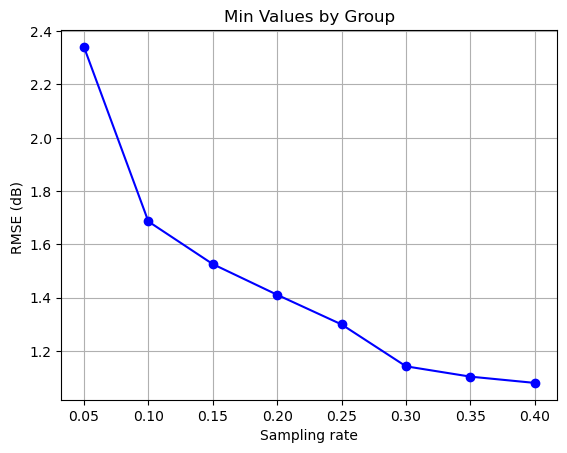

In [10]:
baseline_ln=plot_eval_loss(baseline_d1)

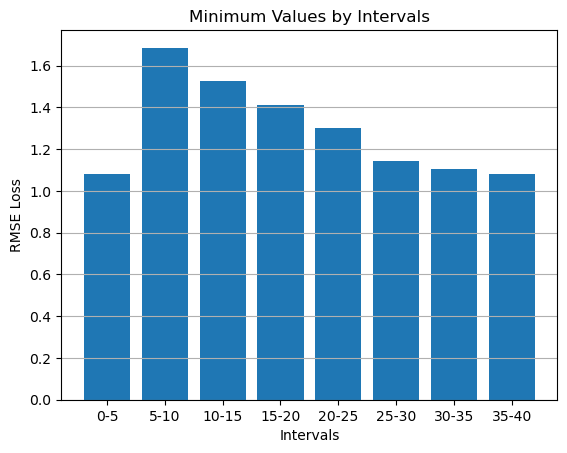

In [11]:
per_d1=plot_percentages(baseline_ln)